In [3]:
# Importing libraries required for data analysis.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [4]:
# Importing Both unemployment datasets

df1 = pd.read_excel("Unemployment in India.xlsx")
df2 = pd.read_excel("Unemployment_Rate_upto_11_2020.xlsx")

In [5]:
# Displaying first five rows.

print("Historical Dataset")
display(df1.head())

print("Covid Dataset")
display(df2.head())

Historical Dataset


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


Covid Dataset


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [6]:
# Checking rows and columns.
# It gives the overall size of datasets.

print("Historical Dataset Shape")
print(df1.shape)
print()
print("Covid Dataset Shape")
print(df2.shape)

Historical Dataset Shape
(754, 7)

Covid Dataset Shape
(267, 9)


In [7]:
# Displaying information about columns and data types.
df1.info()

print("\n")

df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 754 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 41.4 KB


<class 'pandas.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    ------

In [8]:
# Checking missing values in datasets.
# Missing values may affect analysis.

print(df1.isnull().sum())

print()

print(df2.isnull().sum())

Region                                      14
 Date                                       14
 Frequency                                  14
 Estimated Unemployment Rate (%)            14
 Estimated Employed                         14
 Estimated Labour Participation Rate (%)    14
Area                                        14
dtype: int64

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Region.1                                    0
longitude                                   0
latitude                                    0
dtype: int64


In [9]:
# Removing missing values from both datasets

df1 = df1.dropna()
df2 = df2.dropna()

In [10]:
# Checking duplicate rows.
# Duplicate records can affect analysis.

print("Duplicates in Historical Dataset :")
print(df1.duplicated().sum())
print()
print("Duplicates in Covid Dataset :")
print(df2.duplicated().sum())

Duplicates in Historical Dataset :
0

Duplicates in Covid Dataset :
0


In [11]:
# Removing unnecessary spaces from column names.
# Clean names make coding easier.

df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()
print(df1.columns)
print()
print(df2.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='str')


In [12]:
# Converting Date column to datetime format.
# This helps analyze unemployment over time.

df1['Date'] = pd.to_datetime(
    df1['Date'],
    dayfirst=True
)
df2['Date'] = pd.to_datetime(
    df2['Date'],
    dayfirst=True
)

In [13]:
# Generating statistical summary.
# It shows mean, min, max and quartiles.

df1.describe()
 

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


In [14]:
df2.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude
count,267,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,2020-06-16 09:15:30.337078,12.236929,1.396211e+07,41.681573,22.826048,80.532425
min,2020-01-31 00:00:00,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,2020-03-31 00:00:00,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,2020-06-30 00:00:00,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,2020-08-31 00:00:00,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,2020-10-31 00:00:00,75.850000,5.943376e+07,69.690000,33.778200,92.937600
std,NaN,10.803283,1.336632e+07,7.845419,6.270731,5.831738


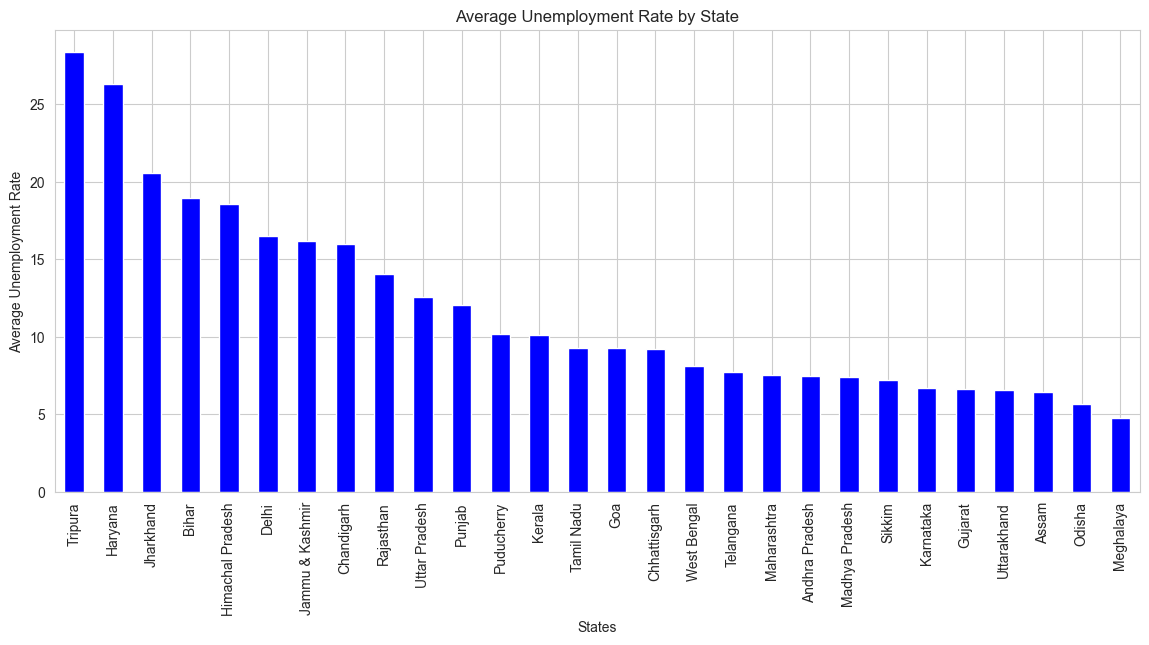

In [ ]:
# Visualizing average unemployment rate by state

state_unemployment = df1.groupby(
    df1.columns[0]
)[df1.columns[3]].mean().sort_values(ascending=False)

plt.figure(figsize=(14,6))

state_unemployment.plot(kind="bar", color="blue")

plt.title("Average Unemployment Rate by State")
plt.xlabel("States")
plt.ylabel("Average Unemployment Rate")

plt.xticks(rotation=90)
plt.show()


In [16]:
# Calculating average unemployment for Rural and Urban areas.
# This helps compare unemployment levels.

area_data = df1.groupby(
    'Area'
)['Estimated Unemployment Rate (%)'].mean()
area_data

Area
Rural    10.324791
Urban    13.166614
Name: Estimated Unemployment Rate (%), dtype: float64

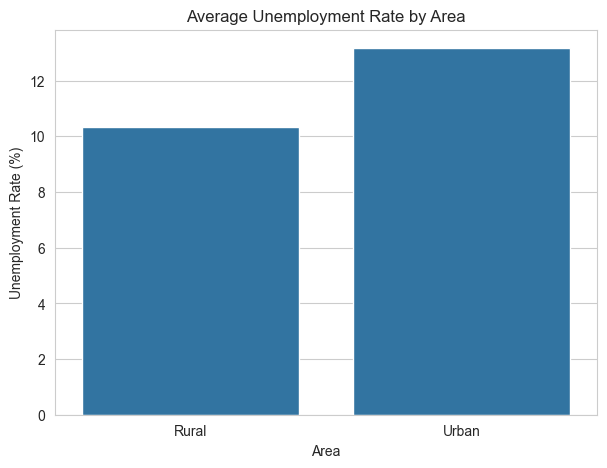

In [17]:
# Visualizing unemployment by area.
# Bar chart makes comparison easy.

plt.figure(figsize=(7,5))
sns.barplot(
    x=area_data.index,
    y=area_data.values
)
plt.title(
    "Average Unemployment Rate by Area"
)
plt.xlabel("Area")

plt.ylabel(
    "Unemployment Rate (%)"
)
plt.savefig(
    "../images/area_wise_analysis.png",
    bbox_inches="tight"
)
plt.show()

C:\Users\Akhilesh\AppData\Local\Temp\ipykernel_22276\2053567440.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


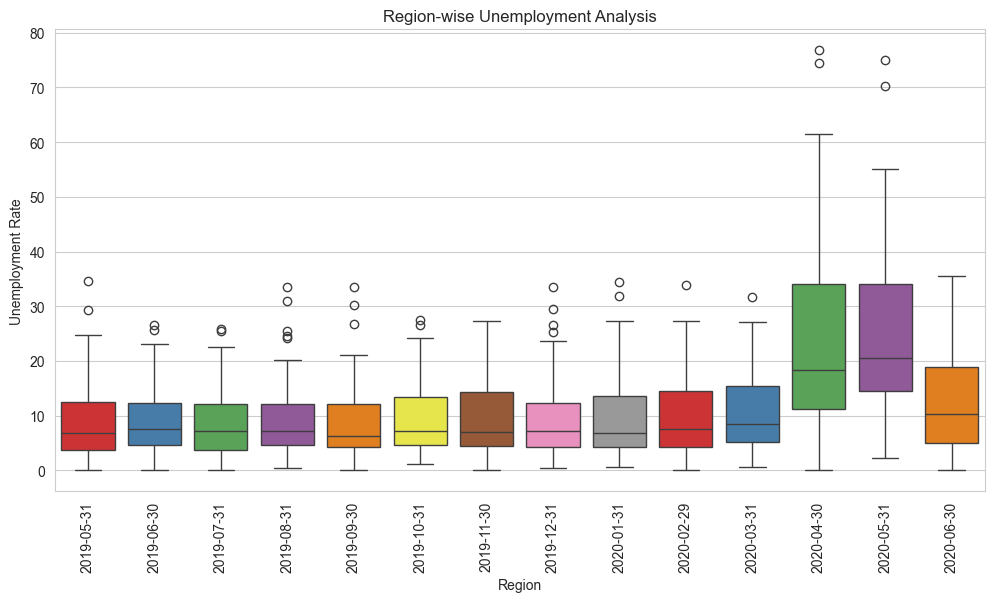

In [18]:
# Visualizing unemployment rate region-wise

plt.figure(figsize=(12,6))

sns.boxplot(
    x=df1.iloc[:,1],
    y=df1.iloc[:,3],
    palette="Set1"
)

plt.xticks(rotation=90)

plt.title("Region-wise Unemployment Analysis")
plt.xlabel("Region")
plt.ylabel("Unemployment Rate")

plt.show()

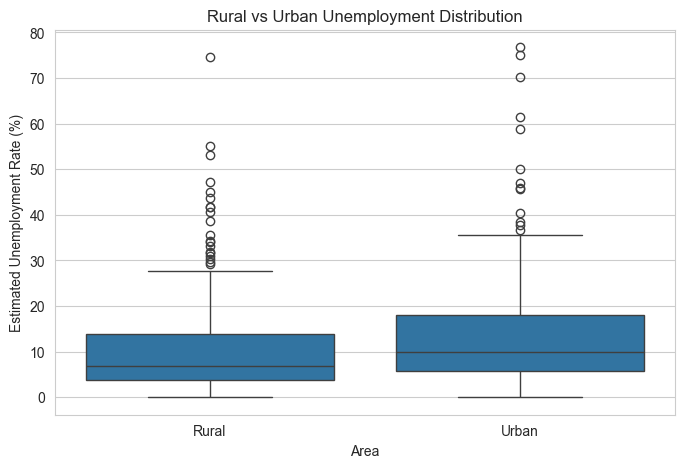

In [ ]:
# Comparing unemployment distribution in Rural and Urban areas.
# Boxplot helps identify spread and outliers.

plt.figure(figsize=(8,5))
sns.boxplot(
    x='Area',
    y='Estimated Unemployment Rate (%)',
    data=df1
)
plt.title(
    "Rural vs Urban Unemployment Distribution"
)
plt.show()

In [20]:
# Extracting month from Date column.
# This helps analyze monthly unemployment patterns.

df1['Month'] = df1['Date'].dt.month
monthly_trend = df1.groupby(
    'Month'
)['Estimated Unemployment Rate (%)'].mean()
monthly_trend

Month
1      9.950755
2      9.964717
3     10.700577
4     23.641569
5     16.646190
6     10.553462
7      9.033889
8      9.637925
9      9.051731
10     9.900909
11     9.868364
12     9.497358
Name: Estimated Unemployment Rate (%), dtype: float64

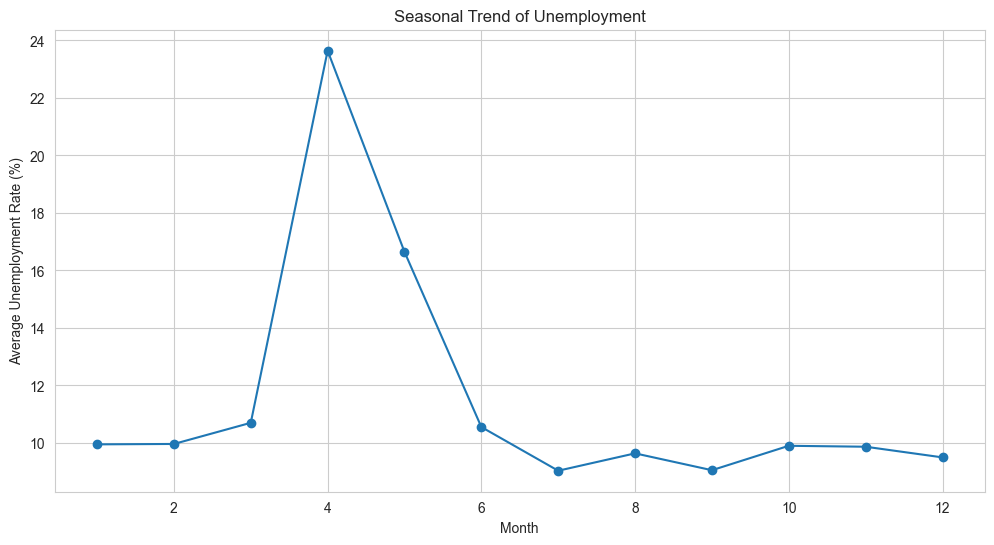

In [21]:
# Plotting seasonal unemployment trend.
# This helps identify monthly fluctuations.

plt.figure(figsize=(12,6))
plt.plot(
    monthly_trend.index,
    monthly_trend.values,
    marker='o'
)
plt.title(
    "Seasonal Trend of Unemployment"
)
plt.xlabel("Month")
plt.ylabel(
    "Average Unemployment Rate (%)"
)
plt.savefig(
    "../images/seasonal_trend.png",
    bbox_inches="tight"
)
plt.show()

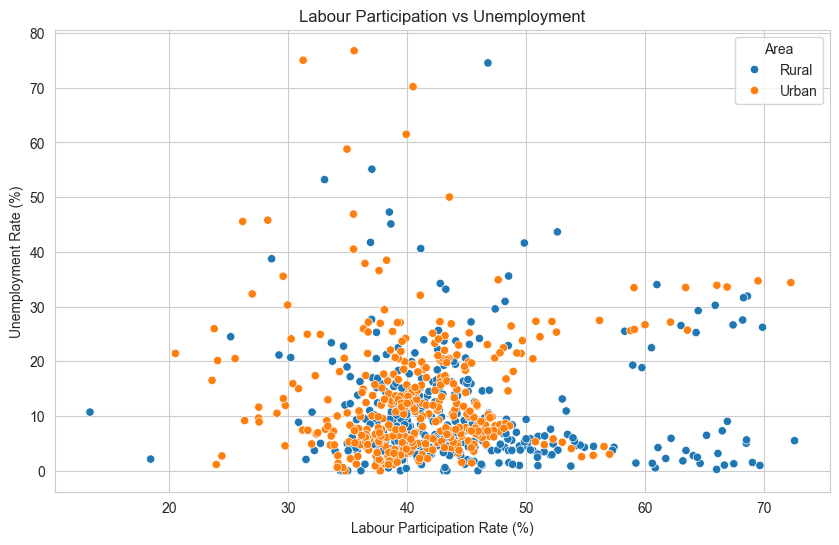

In [22]:
# Relationship between labour participation and unemployment.
# This helps understand labour market dynamics.

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df1,
    x='Estimated Labour Participation Rate (%)',
    y='Estimated Unemployment Rate (%)',
    hue='Area'
)

plt.title(
    "Labour Participation vs Unemployment"
)

plt.xlabel(
    "Labour Participation Rate (%)"
)

plt.ylabel(
    "Unemployment Rate (%)"
)

plt.show()

Insight:

Higher labour participation does not always result in lower unemployment.

This suggests that workforce participation alone cannot solve unemployment without sufficient job creation.

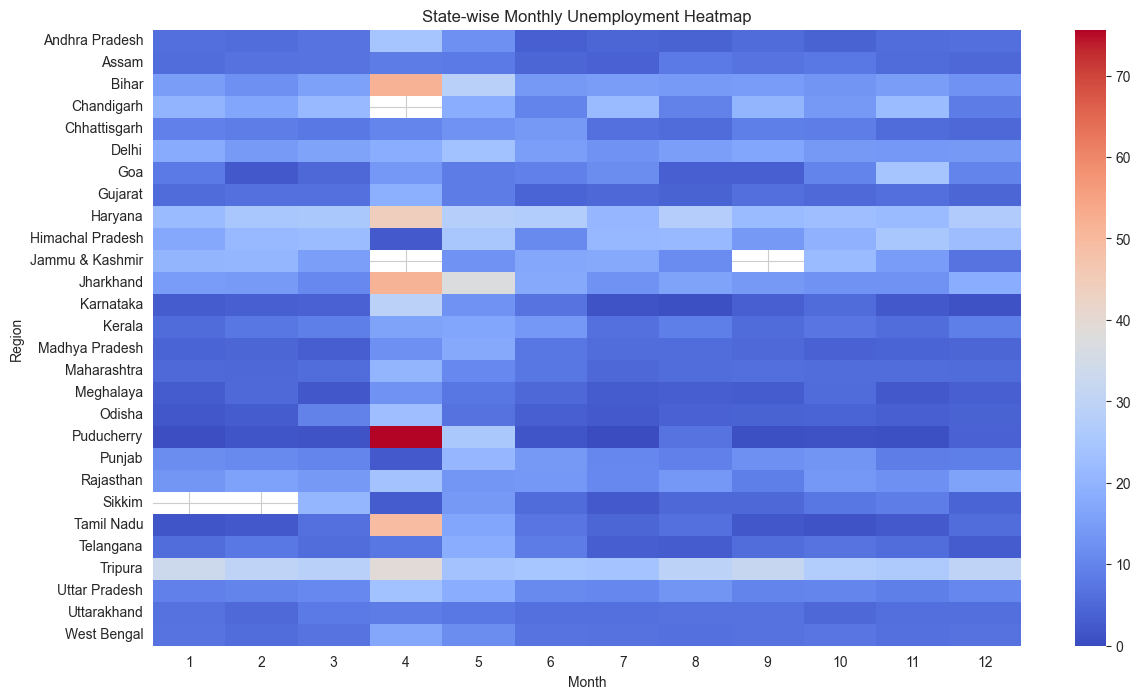

In [32]:
# Creating state-wise monthly unemployment heatmap.
# Heatmap shows patterns across states and months.

pivot_table = df1.pivot_table(
    values='Estimated Unemployment Rate (%)',
    index='Region',
    columns='Month'
)
plt.figure(figsize=(14,8))
sns.heatmap(
    pivot_table,
    cmap='coolwarm'
)
plt.title(
    "State-wise Monthly Unemployment Heatmap"
)
plt.show()

In [24]:
# Comparing unemployment before and after Covid.
# Covid caused significant economic disruptions.

before_covid = df2[
    df2['Date']<'2020-03-01'
]['Estimated Unemployment Rate (%)'].mean()
after_covid = df2[
    df2['Date']>='2020-03-01'
]['Estimated Unemployment Rate (%)'].mean()
print(
    "Average Before Covid :",
    round(before_covid,2)
)
print(
    "Average During Covid :",
    round(after_covid,2)
)

Average Before Covid : 9.23
Average During Covid : 12.96


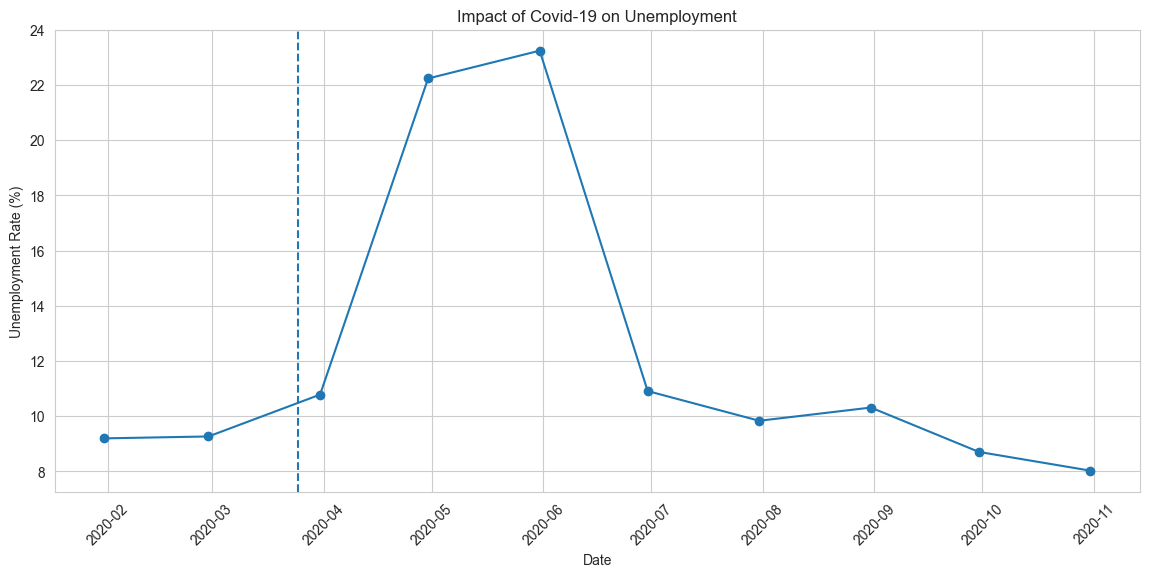

In [31]:
# Visualizing unemployment during Covid period.
# Lockdown date is marked on the graph.

covid_trend = df2.groupby(
    'Date'
)['Estimated Unemployment Rate (%)'].mean()
plt.figure(figsize=(14,6))
plt.plot(
    covid_trend.index,
    covid_trend.values,
   marker='o'
)
plt.axvline(
    pd.to_datetime('2020-03-25'),
    linestyle='--'
)
plt.title(
    "Impact of Covid-19 on Unemployment"
)
plt.xlabel("Date")
plt.ylabel(
    "Unemployment Rate (%)"
)
plt.xticks(rotation=45)
plt.show()

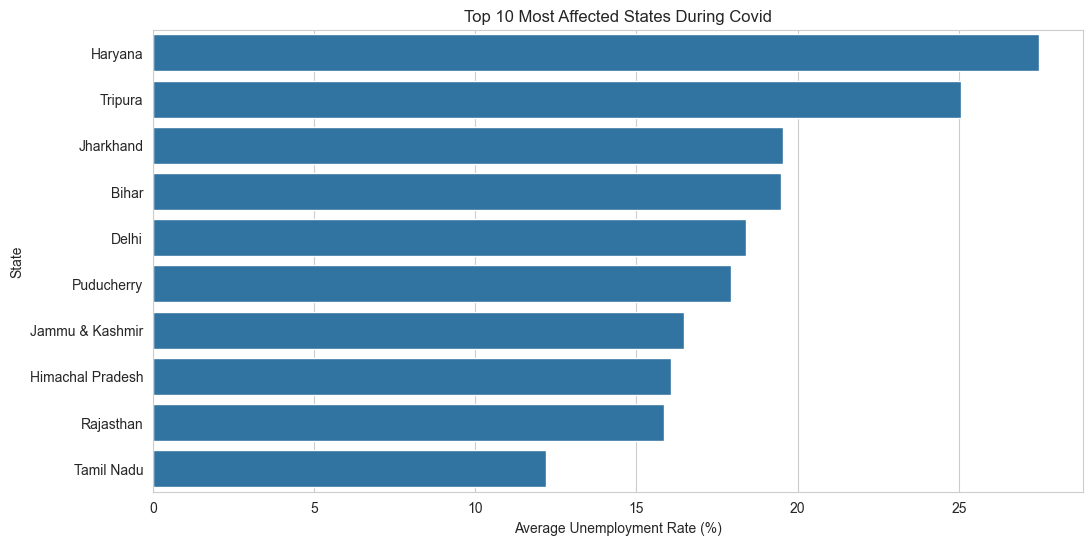

In [26]:
# Finding states most affected during Covid.

covid_state = df2.groupby(
    'Region'
    )['Estimated Unemployment Rate (%)'].mean()
covid_state = covid_state.sort_values(
    ascending=False
)
plt.figure(figsize=(12,6))
sns.barplot(
    x=covid_state.head(10).values,
    y=covid_state.head(10).index
)
plt.title(
    "Top 10 Most Affected States During Covid"
)
plt.xlabel(
   "Average Unemployment Rate (%)"
)
plt.ylabel(
    "State")
plt.show()

Insight:

Several states experienced significantly higher unemployment during Covid-19.

These states may require stronger employment recovery initiatives.

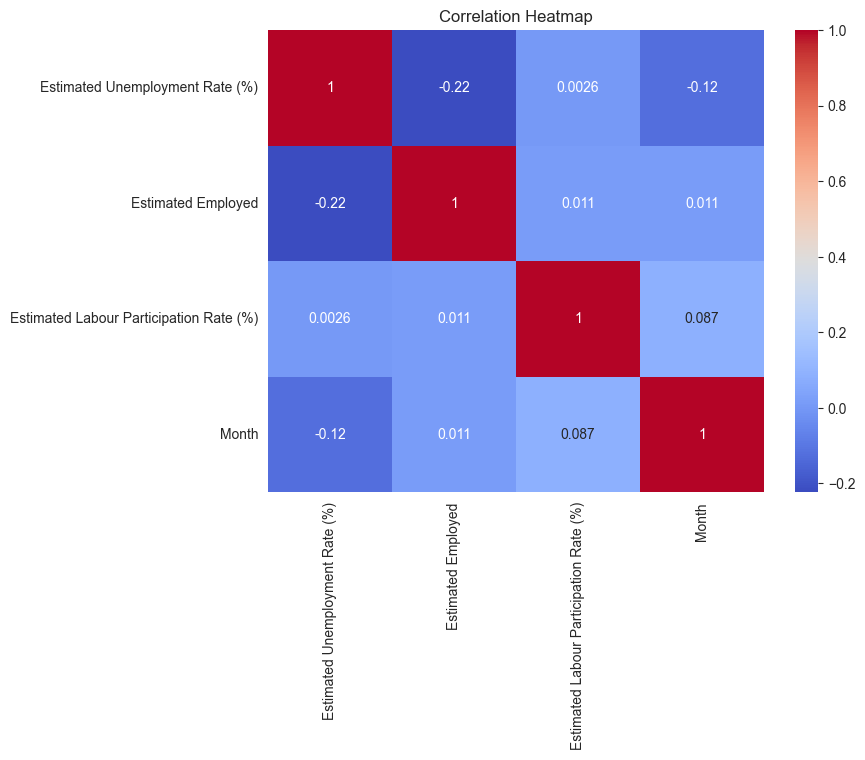

In [30]:
# Finding relationships among numerical variables.
# Heatmap helps visualize correlations.

plt.figure(figsize=(8,6))
sns.heatmap(
    df1.select_dtypes(
        include=np.number
    ).corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title(
    "Correlation Heatmap"
)
plt.show()

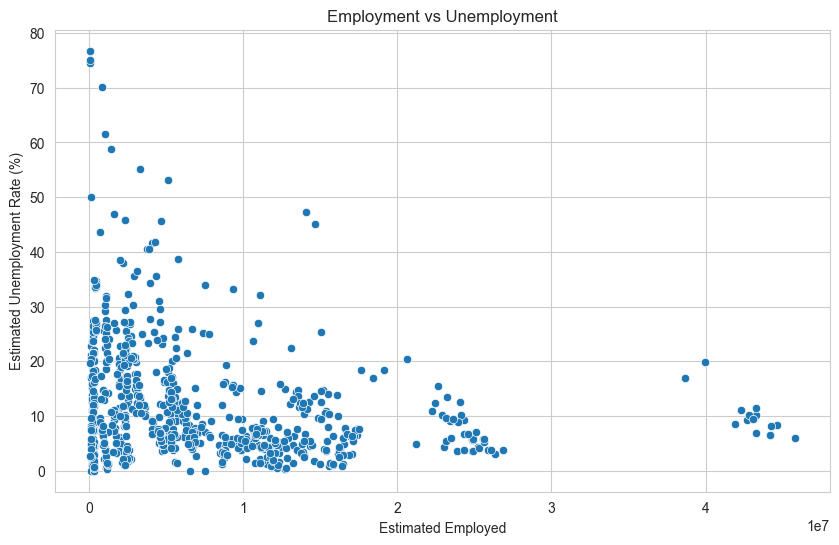

In [28]:
# Relationship between employed population and unemployment.

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df1,
    x='Estimated Employed',
    y='Estimated Unemployment Rate (%)'
)

plt.title(
    "Employment vs Unemployment"
)

plt.show()

Insight:

Regions with larger employed populations generally tend to show lower unemployment rates.

Population size also influences this relationship.

## Conclusion

- Covid-19 significantly increased unemployment in India.
- Unemployment rates vary across states.
- Data visualization helps identify important employment trends.